In [1]:
# PyTorch core imports
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch import nn
from torch.nn import functional as F

from accelerate.test_utils.testing import get_backend
device, n_devices, mem = get_backend()

# gpu setup


# Common scientific computing imports
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# System and utility imports
import os
import sys
import time
import random
from pathlib import Path
from typing import List, Tuple, Dict, Optional, Union

# Optional but commonly used imports
from tqdm.notebook import tqdm  # for progress bars
import logging  # for logging
from datetime import datetime  # for timestamping 

# huggingface imports
from transformers import AutoTokenizer, AutoModelForCausalLM

In [2]:
from scripts.orientation_stim import grating, gabor, circular_mask, broadband_noise

In [ ]:
def circular_mse(x1,x2):
    """ Returns MSE, but if distance is greater than pi/2 then choose the shorter circular path.
    pi/2 instead of pi since orientation repeats at pi"""
    x2p = torch.where((x1-x2)>np.pi/2, x2+np.pi, x2)
    x1p = torch.where((x2-x1)>np.pi/2, x1+np.pi, x1)
    r1= F.mse_loss(x1p,x2p)
    return r1

def get_rot_mat(theta, device=device):
    if isinstance(theta,torch.Tensor):
        theta = theta.to(device).clone().detach()
    else:
        theta = torch.tensor(theta, device=device)
    return torch.tensor([[torch.cos(theta), -torch.sin(theta), 0],
                         [torch.sin(theta), torch.cos(theta), 0]], device=device)


def rot_img(x, theta, dtype,device=device):
    rot_mat = get_rot_mat(theta, device=device)[None, ...].type(dtype).repeat(x.shape[0],1,1)
    grid = F.affine_grid(rot_mat, x.size(),align_corners=False).type(dtype)
    x = F.grid_sample(x, grid, align_corners=False, )
    return x

blur_mask = torch.tensor(circular_mask(64, pixelsPerDegree=30,if_filtered=True), dtype=torch.float32, device=device)
                         
def sinusoid(freq,phase=0, orientation=0, device=device):
    arr= torch.ones(1,1,64,64, device=device)
    arr*=torch.linspace(0,3.14159,64, device=device)
    arr2d = torch.cos(freq*arr+phase)
    arr2d = rot_img(arr2d, orientation + np.pi/2, arr2d.dtype, device=device)[0,0]
    x, y = torch.meshgrid(torch.arange(64, device=device), torch.arange(64, device=device))
    x = (x - 64 / 2.0)
    y = (y - 64 / 2.0)
    arr2d *= blur_mask
    return arr2d[None]

def get_sensitivity(func, i, eps=1e-3):
    diff= (func(i+eps) - func(i-eps))/(2*eps)
    return diff.pow(2).sum()

def one_hot_orientation(o, n_bins=60):
    # first bin
    o = (o /np.pi * n_bins).to(int)
    return F.one_hot(o.squeeze(), n_bins)

def discretize(o,n_bins=60):
    assert o.max() <= np.pi and o.min()>=0
    o = (o /np.pi * n_bins).to(int)
    return o.squeeze()

def noise_labels(y, ps):
    """Applies Bernoulli noise on the output labels with probability
    ps. p=1 corresponds to no noise. In the event of a noise-induced dropout, places mass on a null category.
    Assumes y is not 1hot but rather numerical category indicator, like F.nll_loss"""
    n_categories = len(ps)
    not_dropped = torch.bernoulli(ps[y]).to(y.device)
    y = torch.where(not_dropped.bool(), y, n_categories)
    return y

def fake_noise_labels(y,ps):
    """ACts like noise_labels, but goes as deterministically as possible, dropping as close to 1-ps proportion
    as doable"""
    for l in range(len(ps)):
        idx = torch.where(y==l)[0]
        n_to_drop = int(len(idx) - len(idx)*ps[l])
        y[idx[:n_to_drop]] = len(ps)
    return y

class my_pdf(scipy.stats.rv_continuous):
    def _pdf(self,x):
        return (-np.cos(2*x)+2)/(2*np.pi)

/Users/jrudoler/miniconda3/envs/torch_env/lib/python3.11/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1729647038473/work/aten/src/ATen/native/TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


(-0.5, 63.5, 63.5, -0.5)

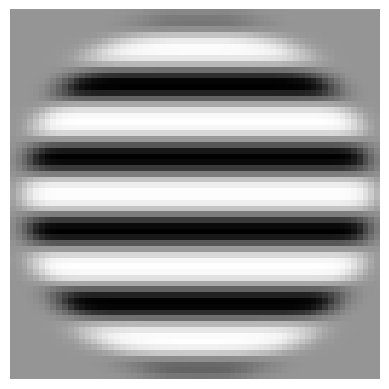

In [4]:
plt.imshow(sinusoid(10,0,0)[0].cpu(), cmap='Greys')
plt.axis('off')

In [5]:
class FFNet(nn.Module):
    def __init__(self, scale=1, n_out=60, linear=False):
        super().__init__()
        self.linear1 = nn.Sequential(nn.Linear(64**2, 32**2)) if linear else nn.Sequential(nn.Linear(64**2, 32**2),nn.ReLU())
        self.linear2 = nn.Sequential(nn.Linear(32**2, 16**2)) if linear else nn.Sequential(nn.Linear(32**2, 16**2),nn.ReLU(),)
        self.linear3 = nn.Sequential(nn.Linear(16**2, n_out))
        self.n_out = n_out
        for mod in (self.linear1, self.linear2, self.linear3):
            mod[0].weight.data *= scale
            mod[0].bias.data *= scale
        
    def forward(self,x):
        low = self.linear1(x.view(-1,64**2))
        mid = self.linear2(low)
        top = self.linear3(mid) 
        theta = F.log_softmax(top,1)
        return low,mid,theta.view(-1,self.n_out)
    

  0%|          | 0/300 [00:00<?, ?it/s]

KeyboardInterrupt: 

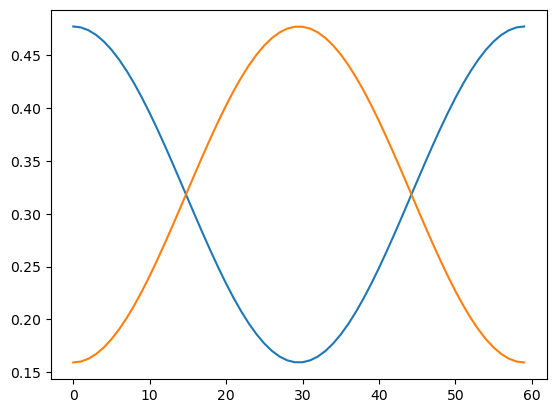

In [7]:
n_out = 60
my_cv = my_pdf(a=0, b=np.pi)
class my_pdf_inv(scipy.stats.rv_continuous):
    def _pdf(self,x):
        return (np.cos(2*x)+2)/(2*np.pi)
my_cv_inv = my_pdf_inv(a=0, b=np.pi)
plt.plot(my_cv_inv._pdf(torch.linspace(0,np.pi,n_out)), label="PDF")
plt.plot(my_cv._pdf(torch.linspace(0,np.pi,n_out)), label="PDF")

net = FFNet(.1,n_out=n_out).to(device)
optim = torch.optim.SGD(net.parameters(),.5)
net.train()
losses = []
batch = 2048

pdf = lambda x: (torch.cos(2*x)+2)/(2*np.pi)
orientations= torch.linspace(0,np.pi,n_out, device=device)

all_sensitivity = []
# plt.figure()
# ax = plt.gca()
cat_of_interest = [0,15,30]
accuracy_by_category = -torch.ones(300,n_out)
for i in tqdm(range(300)):
    
    if 0:
#         f,axs = plt.subplots(1,2,figsize=(10,5))
        
#         plot_map_sin(net,ax=axs[0], n_bins=n_out)
#         all_sensitivity.append(plot_sensitivity(net,layer=0))
#         plt.show()
        
        plot_external_noise_curve(net, n=30,n_phases=100,ax=ax, layer=0, o=np.pi/2)

        
    
    # make x
    orientations = torch.tensor(my_cv.rvs(size=batch), dtype=torch.float32, device=device)
#     orientations = torch.rand(batch, device="cuda:0")*np.pi
    
    ####
    optim.zero_grad()
    orientation_stim = [sinusoid(10,torch.rand(1, device=device)*np.pi,o, device=device) for o in orientations]
    orientation_stim = torch.stack(orientation_stim)[:,None].to(device)

    
    y = discretize(orientations, n_out)
    noised_y = noise_labels(y,torch.ones(n_out, device=y.device)*.1
                            #inverse_binary_entropy_lookup(h)
                           )
        
    low,mid,o_est = net(orientation_stim)
    Y_hat = torch.cat((o_est, torch.zeros(batch,1, device=o_est.device)),dim=1) # don't train the null
    
    loss = F.nll_loss(Y_hat, noised_y.squeeze())
    loss.backward()
    optim.step()   
    ####
    overall_acc = (y==o_est.argmax(1)).sum().float()/batch
    for cat in cat_of_interest:
        orientations = (torch.rand(2000, device=device)+cat)*np.pi/60

        ####
        optim.zero_grad()
        orientation_stim = [sinusoid(10,torch.rand(1, device=device)*np.pi,o, device=device) for o in orientations]
        orientation_stim = torch.stack(orientation_stim)[:,None].to(device)
        y = discretize(orientations, n_out)
        low,mid,o_est = net(orientation_stim)       
        
        idx = torch.where(y==cat)[0]
        if len(idx)>0:
            accuracy_by_category[i,cat] = (y[idx]==o_est[idx].argmax(1)).sum().float()/len(idx)
    
    
    losses.append(overall_acc.item())

# plt.show()